<a href="https://colab.research.google.com/github/blossomkaler/agentic-ai-fdp/blob/main/agentic_fdp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Run this in your FIRST Colab cell
!pip install pandas==2.2.2 scikit-learn==1.5.1 joblib==1.4.2 matplotlib==3.9.0 -q
print("✅ Tools installed. You're ready to go.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 51.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 301.8/301.8 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 65.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.1 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.1 which is incompatible.
✅ Tools installed. You're ready to go.


In [ ]:
# Download the Telco Churn CSV directly into Colab (no login needed)
!wget -q https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv -O telco_churn.csv

print("✅ Downloaded telco_churn.csv")

# Confirm the file is here
import os
print("File size:", round(os.path.getsize("telco_churn.csv") / 1024, 1), "KB")

✅ Downloaded telco_churn.csv
File size: 947.7 KB


In [ ]:
import pandas as pd

# Read the CSV file into a "DataFrame" — pandas's name for a table
df = pd.read_csv("telco_churn.csv")

# How big is it? (rows, columns)
print("Shape:", df.shape)          # (7043, 21) -> 7043 customers, 21 columns

# Peek at the first 5 rows
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# HYPOTHESIS 1: Do newer customers churn more?
# Compare the average tenure (months as a customer) of leavers vs stayers.
print("Average months as a customer:")
print(df.groupby("Churn")["tenure"].mean().round(1))
# Expected: customers who churned have MUCH lower average tenure

Average months as a customer:
Churn
No     37.6
Yes    18.0
Name: tenure, dtype: float64


In [ ]:
# HYPOTHESIS 2: Do month-to-month customers churn more?
# Group by contract type and show the % who churned in each group.
churn_by_contract = df.groupby("Contract")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
).round(1)
print("Churn rate by contract type (%):")
print(churn_by_contract)
# Expected: Month-to-month ~43%, One year ~11%, Two year ~3%

Churn rate by contract type (%):
Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn, dtype: float64


In [ ]:
# HYPOTHESIS 3: Do fiber-optic internet customers churn more?
churn_by_internet = df.groupby("InternetService")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
).round(1)
print("Churn rate by internet type (%):")
print(churn_by_internet)
# Expected: Fiber optic churns highest, "No internet" churns lowest

Churn rate by internet type (%):
InternetService
DSL            19.0
Fiber optic    41.9
No              7.4
Name: Churn, dtype: float64


In [ ]:
# HYPOTHESIS 5: Does gender actually matter?
churn_by_gender = df.groupby("gender")["Churn"].apply(
    lambda x: (x == "Yes").mean() * 100
).round(1)
print("Churn rate by gender (%):")
print(churn_by_gender)
# Expected: almost identical for Male and Female — gender barely matters

Churn rate by gender (%):
gender
Female    26.9
Male      26.2
Name: Churn, dtype: float64


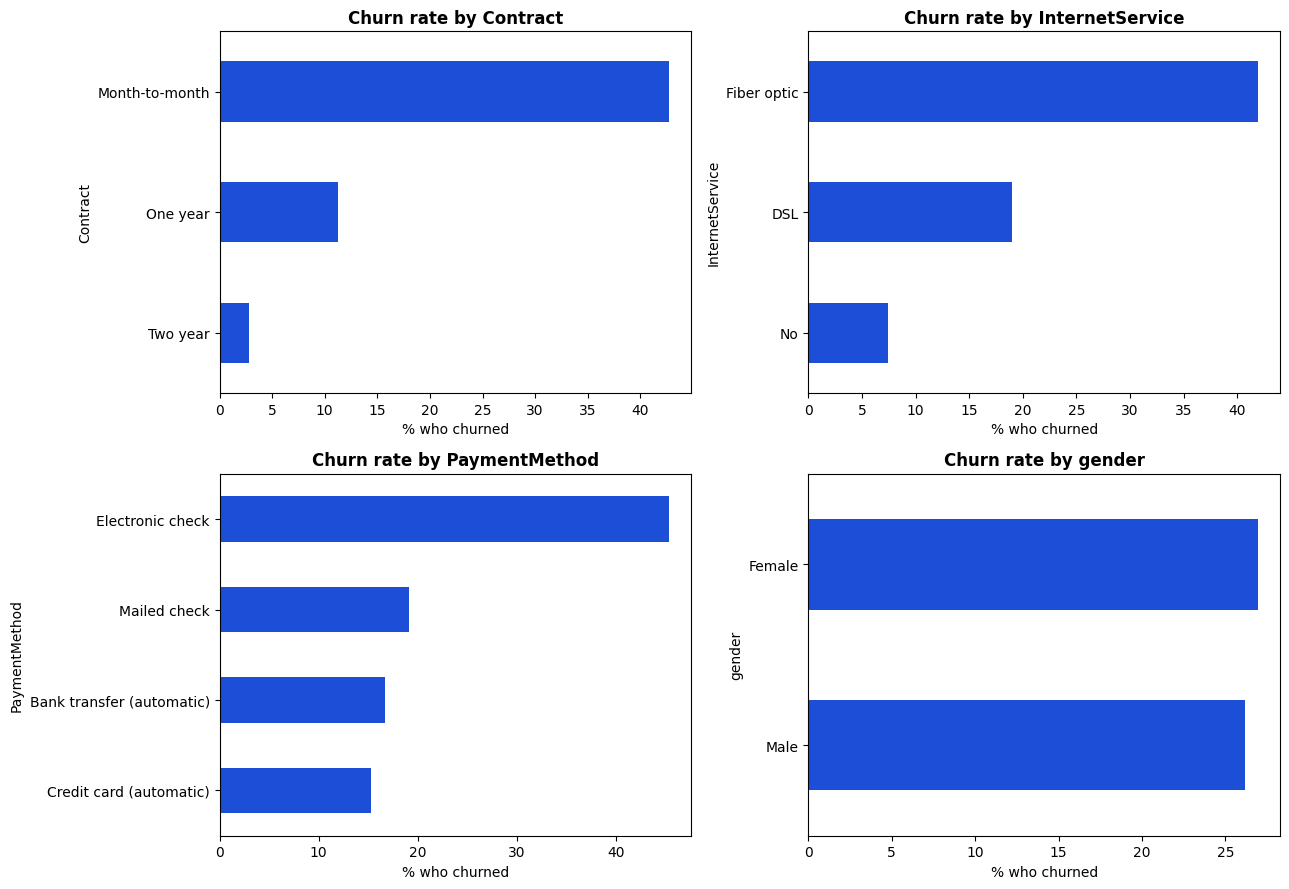

In [ ]:
import matplotlib.pyplot as plt

# Pick the columns we found most interesting
cols_to_plot = ["Contract", "InternetService", "PaymentMethod", "gender"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flatten(), cols_to_plot):
    rates = df.groupby(col)["Churn"].apply(lambda x: (x == "Yes").mean() * 100)
    rates.sort_values().plot(kind="barh", ax=ax, color="#1d4ed8")
    ax.set_title(f"Churn rate by {col}", fontweight="bold")
    ax.set_xlabel("% who churned")

plt.tight_layout()
plt.show()

In [ ]:
# 1. What columns exist, and what type is each?
df.info()

# 2. Look at the TARGET — the thing we predict. Is it balanced?
print(df["Churn"].value_counts(normalize=True))
# No     0.73   -> 73% of customers stayed
# Yes    0.27   -> 27% of customers left

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Convert the column to numbers. Blanks that can't convert become "NaN" (missing)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# How many are missing now?
print("Missing values:", df["TotalCharges"].isna().sum())   # 11

# These are new customers, so a sensible value is 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

Missing values: 11


In [ ]:
# Remove the customer ID — it's just a random code with no useful pattern
df = df.drop(columns=["customerID"])

# y = the answer we want to predict. Convert "Yes"/"No" to 1/0 (computers prefer numbers)
y = (df["Churn"] == "Yes").astype(int)

# X = everything else (all the input features)
X = df.drop(columns=["Churn"])

In [ ]:
# Numeric columns (e.g. tenure, MonthlyCharges)
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Text/category columns (e.g. gender, Contract type)
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numbers:", numeric_features)
print("Categories:", categorical_features)

Numbers: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categories: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,         # keep 20% hidden for testing
    random_state=42,        # makes the split identical every time you run it
    stratify=y              # keep the same 73/27 ratio in both halves
)

print(f"Training on {X_train.shape[0]} customers, testing on {X_test.shape[0]}")

Training on 5634 customers, testing on 1409


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# --- Recipe for NUMERIC columns: fill missing -> put on common scale ---
numeric_steps = Pipeline(steps=[
    ("fill_missing", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

# --- Recipe for TEXT columns: fill missing -> convert to numbers ---
categorical_steps = Pipeline(steps=[
    ("fill_missing", SimpleImputer(strategy="most_frequent")),
    ("to_numbers", OneHotEncoder(handle_unknown="ignore")),
])

# --- Apply each recipe to the right columns ---
preprocessor = ColumnTransformer(transformers=[
    ("numbers", numeric_steps, numeric_features),
    ("categories", categorical_steps, categorical_features),
])

# --- The complete model: preparation + the learning algorithm, in ONE object ---
model = Pipeline(steps=[
    ("prepare", preprocessor),
    ("learn", LogisticRegression(max_iter=1000, random_state=42)),
])

# Train the model on the training data only
model.fit(X_train, y_train)
print("Model trained!")

Model trained!


In [ ]:
preprocessor

ColumnTransformer(transformers=[('numbers',
                                 Pipeline(steps=[('fill_missing',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('categories',
                                 Pipeline(steps=[('fill_missing',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('to_numbers',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")

print(f"Average accuracy: {scores.mean():.3f}")
print(f"Variation (+/-):  {scores.std():.3f}")
print(f"Baseline to beat: 0.730")
print(scores)

Average accuracy: 0.804
Variation (+/-):  0.014
Baseline to beat: 0.730
[0.83052351 0.80212955 0.80567879 0.79148181 0.79129663]


In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

# A helper that wraps any algorithm in our shared preparation pipeline
def build_model(algorithm):
    return Pipeline(steps=[
        ("prepare", preprocessor),
        ("learn", algorithm),
    ])

# The three contenders
candidates = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
}

# Test each one fairly with cross-validation
for name, algorithm in candidates.items():
    pipe = build_model(algorithm)
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="accuracy")
    print(f"{name:<22} {scores.mean():.3f} +/- {scores.std():.3f}")

Logistic Regression    0.804 +/- 0.014
Random Forest          0.791 +/- 0.011
Gradient Boosting      0.802 +/- 0.014


              precision    recall  f1-score   support

      Stayed       0.85      0.89      0.87      1035
     Churned       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



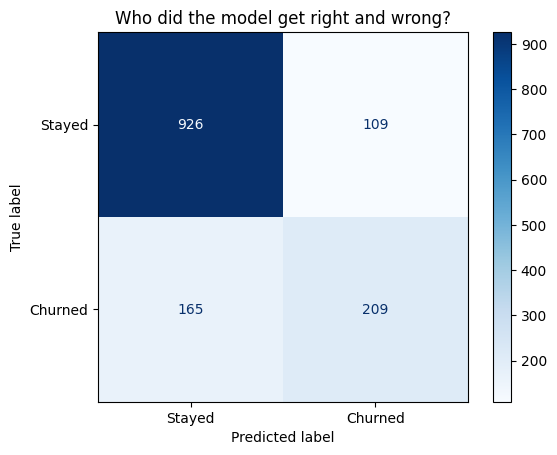

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Train our chosen model and test it on the secret test set
final = build_model(LogisticRegression(max_iter=1000, random_state=42))
final.fit(X_train, y_train)
predictions = final.predict(X_test)

# A full report of how well it did
print(classification_report(y_test, predictions, target_names=["Stayed", "Churned"]))

# Draw the confusion matrix (it appears right under the cell in Colab)
matrix = confusion_matrix(y_test, predictions)
ConfusionMatrixDisplay(matrix, display_labels=["Stayed", "Churned"]).plot(cmap="Blues")
plt.title("Who did the model get right and wrong?")
plt.show()